# 05 · Final Model Selection + Results

**When to run this notebook:** last, once you are comfortable with the training
results (03) and tuning (04). It focuses on the **explicitly selected final
model(s)**, justifies the choice using the evidence gathered across the
sequence, and reserves a slot for the out-of-bounds holdout evaluation planned
for the next implementation pass.

> **Sequence:** notebook 5 of 5. See [notebooks.md](./notebooks.md).

## Configuration

- **`FINAL_MODELS`** — the model(s) selected as final, named explicitly. Defaults
  to `["xgb"]` (XGBoost was the strongest and the ensemble added no meaningful
  gain).
- **`IS_DRY_RUN`** (default `True`) — validation results are not appended to GCS.

This notebook loads the **current committed model version's** artifacts from GCS
(`validate_current`) and narrows them to `FINAL_MODELS` — it does not retrain.

In [ ]:
import sys
import os

# Make the capstone package importable (notebook lives in notebooks/, code in src/capstone/).
sys.path.append(os.path.abspath("../"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pipeline.version_config import VersionConfig
from pipeline.pipeline_run import PipelineRun
from pipeline.factory import PipelineFactory
from pipeline.stages import eda
from utils.snapshot_model import ModelType
from evaluation.segment_auditor import SegmentAuditor

IMAGES_FOLDER = "../../../images/results/"
IS_DRY_RUN = True

# The final selected model(s), specified explicitly.
FINAL_MODELS = ["xgb"]

# IS_DRY_RUN doubles as the figure-write guard: in a dry run we pass save_figure_name=None
# so no image files are written to disk; flip IS_DRY_RUN to False to persist figures.
def fig_path(name):
    return None if IS_DRY_RUN else f"{IMAGES_FOLDER}{name}"

# Metric column order used in every results table below. Global (macro) metrics
# come first, then the per-class above/below breakdown.
#   *_macro = sklearn average="macro" = unweighted mean of above- and below-baseline
#             scores. It is the single "overall" number that weights both classes equally.
METRIC_COLS = [
    "roc_auc", "accuracy",
    "precision_macro", "recall_macro", "f1_macro",
    "precision_above", "recall_above", "f1_above",
    "precision_below", "recall_below", "f1_below",
]

In [ ]:
config = VersionConfig.load().dry_run(IS_DRY_RUN).build()
run = PipelineRun(config)
stages = PipelineFactory.validate_current(config)
print("Scenario:", stages.scenario, "| model version:", config.model_version)

### Load data + final model artifacts

Run the pipeline through scaling, load the saved models for the current version,
then **narrow `run.models` to `FINAL_MODELS`** before validating so every
downstream view focuses on the selected model(s).

In [3]:
stages.loader.run(run)
stages.preprocessor.run(run)
stages.engineer.run(run)
stages.splitter.run(run)
stages.scaler.run(run)
stages.model_loader.run(run)

available = list(run.models.keys())
run.models = {k: v for k, v in run.models.items() if k in FINAL_MODELS}
if not run.models:
    raise ValueError(f"None of FINAL_MODELS={FINAL_MODELS} found. Available: {available}")
print("Final model(s) under evaluation:", list(run.models.keys()))

stages.validator.run(run)

Loaded snapshot 'v3.4_real': 60696 rows from 2026-04-29
  Polls: {'upload': 21398, '24h': 20906, '7d': 18392}
Loaded baselines 'v4.0': 28814 baseline videos, 974 median rows (974 channels)
Building clean dataset
snapshot cols: Index(['video_id', 'poll_timestamp', 'channel_id', 'channel_handle', 'title',
       'view_count', 'like_count', 'comment_count', 'face_count', 'brightness',
       'colorfulness', 'vertical', 'tier', 'description', 'tags',
       'duration_seconds', 'category_id', 'category_name', 'published_at',
       'poll_label', 'hours_since_publish', 'subscriber_count',
       'contains_synthetic_media'],
      dtype='object')

[1/3] Pivoting snapshots...
  Videos with all 3 polls: 18334 (dropped 3111 incomplete)
  Pivoted shape: (18403, 34)

[2/3] Joining baseline medians...
  Baseline join: 18403/18403 videos matched a channel median

[3/3] Cleaning data...
  Dropped 15 row(s) with null contains_synthetic_media (private/failed harvest).
  Cleaned: 18388 rows × 40 columns

PipelineRun(model_version='v5.3', num_synth_rows=0, populated=['df_videos', 'df_baselines', 'df_medians', 'df_clean', 'df_engineered', 'df_train', 'df_test', 'df_val', 'df_gen', 'X_train', 'X_test', 'X_val', 'X_val_unscaled', 'X_gen', 'y_train', 'y_test', 'y_val', 'y_gen', 'models', 'results'])

### A note on the evaluation metrics

Every metrics table in this notebook leads with three **global** scores —
`precision_macro`, `recall_macro`, `f1_macro` — followed by the per-class
breakdown (`*_above`, `*_below`).

The global scores use **sklearn's `average="macro"`**: compute precision /
recall / F1 separately for each class, then take the unweighted mean across
classes. For example, `f1_macro = mean(f1_above, f1_below)`. Because the
target is ~50/50 by design, macro and weighted averages are nearly identical
here — macro is preferred because it treats both classes equally regardless
of exact counts, which matches the intent of a balanced binary target.

The per-class split is retained because the error costs differ — a false
"will overperform" prediction has a different business impact than a false
"will underperform" — but the macro scores are shown first as the headline
numbers.

### Final validation metrics

The selected model(s) on the locked holdout. ROC-AUC is the metric of record;
the macro and per-class breakdowns are shown for completeness.

In [5]:
df_final = pd.DataFrame(run.results).T[METRIC_COLS].astype(float).round(4)
df_final.index.name = "model"
df_final.style.format("{:.4f}")

,roc_auc,accuracy,precision_macro,recall_macro,f1_macro,precision_above,recall_above,f1_above,precision_below,recall_below,f1_below
model,,,,,,,,,,,
xgb,0.9090,0.8301,0.8286,0.8267,0.8275,0.8400,0.8575,0.8487,0.8172,0.7959,0.8064


### ROC curves

True-positive vs. false-positive rate across thresholds for the final model(s)
on the locked validation set.

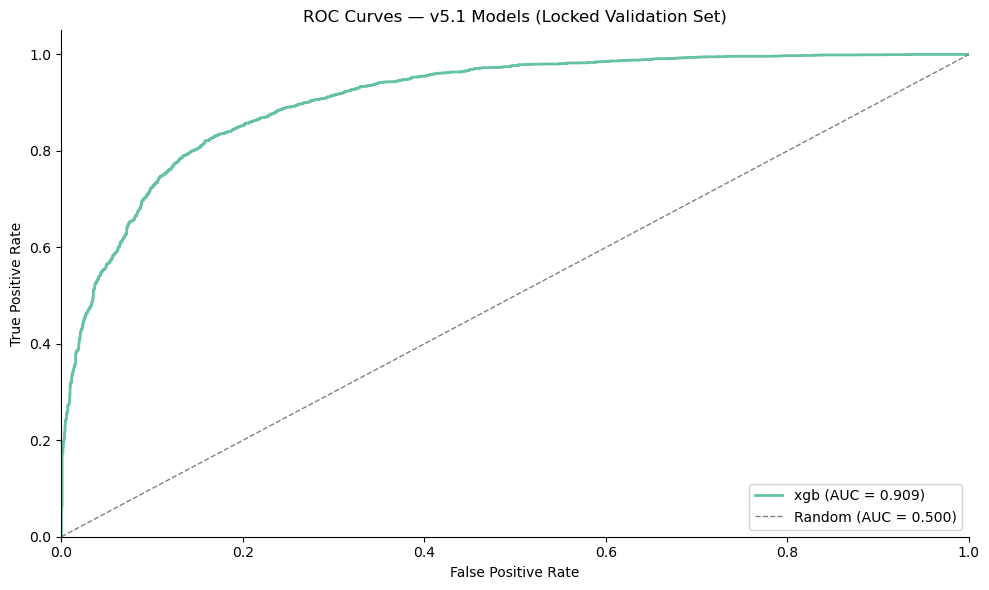

In [6]:
eda.plot_roc_curves(run, save_figure_name=fig_path("roc_auc_curve.png"))

### Segment audit — final model(s)

Re-run the segment audit (as in notebook 03) but only for the final model(s), to
confirm the selected model is acceptable across verticals and tiers — not just on
average. Any flagged blind spot is a known limitation to call out in the report.

In [7]:
df_val_seg = run.df_val
if "vertical" not in df_val_seg.columns or "tier" not in df_val_seg.columns:
    df_val_seg = df_val_seg.merge(
        run.df_clean[["video_id", "vertical", "tier"]], on="video_id", how="left"
    )

auditor = SegmentAuditor(
    models=run.models,
    X_val=run.X_val,
    y_val=run.y_val,
    df_val=df_val_seg,
    threshold=0.5,
)
segment_results = auditor.audit()
auditor.print_summary(segment_results)


  Segment audit — VERTICAL
vertical      xgb  auc    xgb  acc
----------  ----------  ----------
Education       0.8980      0.8245
Lifestyle       0.9296      0.8504
Tech            0.8829      0.8054
ALL             0.9048      0.8272

  Blind spots (roc_auc > 0.03 below global):
    None — model performs uniformly across all segments.

  Segment audit — TIER
tier      xgb  auc    xgb  acc
------  ----------  ----------
L           0.9384      0.8644
M           0.9027      0.8246
S           0.8641      0.7874
ALL         0.9048      0.8272

  Blind spots (roc_auc > 0.03 below global):
    [xgb] tier=S            auc=0.8641  (global=0.9048, drop=0.0407)


### Feature importance — final model

The drivers of the selected model, for the report's "what the model learned"
narrative.

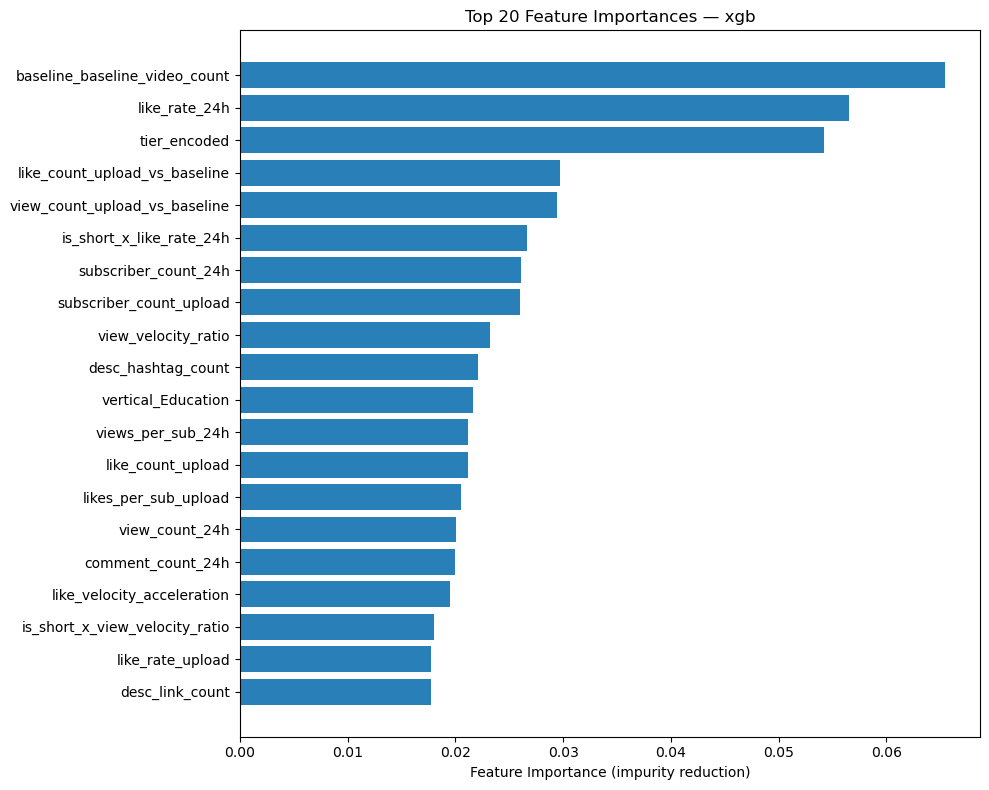

In [8]:
for name in run.models:
    eda.plot_feature_importance(run, model_name=name, top_n=20,
                                save_figure_name=fig_path(f"05_feature_importance_{name}.png"))

### Cross-version trajectory

The historical progression that justifies the final choice (also shown in
notebook 03). The dashed line marks the v4.0 methodology change (locked holdout).

Loaded 33 model snapshots


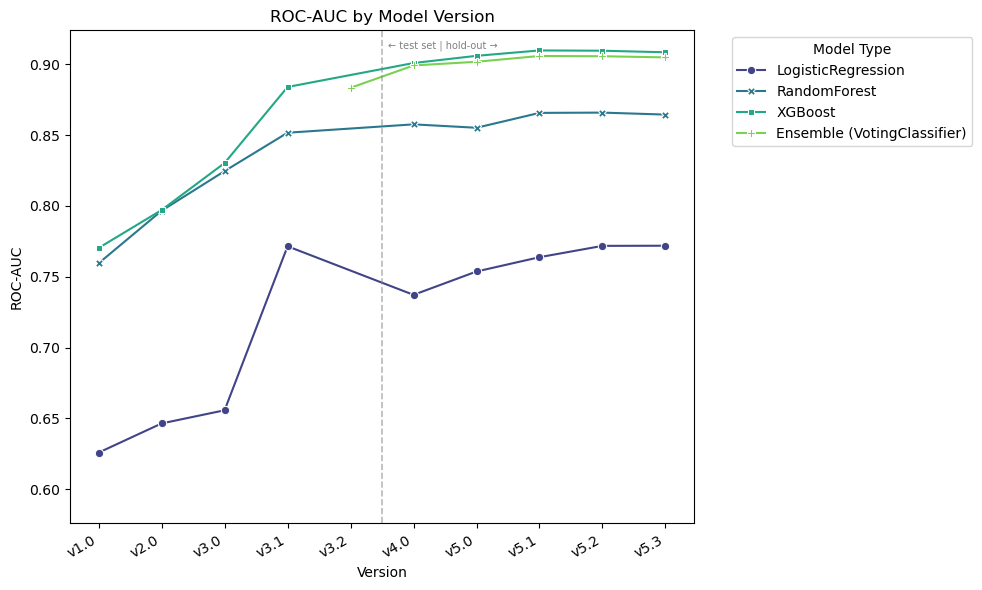

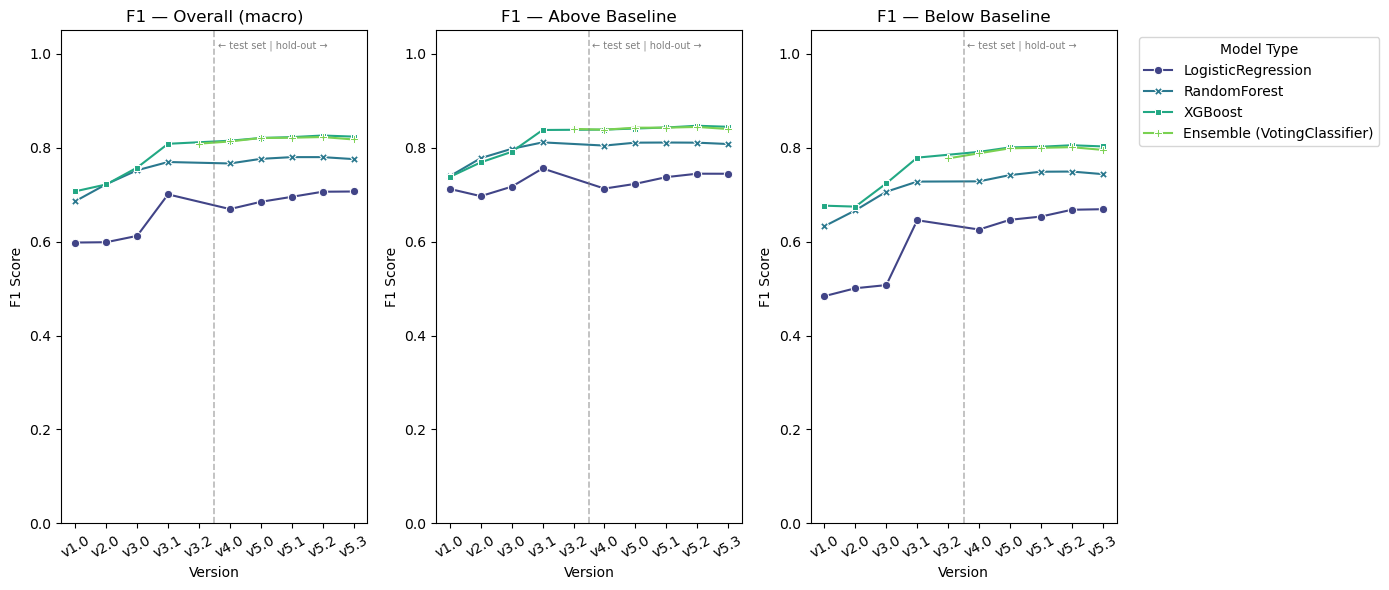

In [9]:
eda.load_model_comparison(run)
eda.plot_roc_auc(run, save_figure_name=fig_path("roc_auc_by_version_line.png"))
eda.plot_f1(run, save_figure_name=fig_path("f1_by_model.png"))

## Out-of-bounds (OOB) holdout — PLACEHOLDER

> **Not yet implemented.** A true out-of-bounds holdout — videos from verticals
> the model never trained on (e.g. Music / Sports) — will be created in the next
> implementation pass to test generalization beyond the three trained verticals.
> `PipelineRun` already reserves `run.df_gen` / `run.X_gen` / `run.y_gen` for
> these "generalization" rows.

The cell below is a guarded stub: it evaluates the final model(s) on the OOB set
once it exists, and otherwise prints a placeholder message. No action is needed
until the OOB set is created.

In [10]:
from dataclasses import asdict
from utils.snapshot_model import ModelResult

oob_available = getattr(run, "X_gen", None) is not None and len(run.X_gen) > 0

if not oob_available:
    print("OOB holdout not yet available — placeholder. "
          "It will be created in the next implementation pass (see notebooks.md).")
else:
    oob_results = {}
    for name, entry in run.models.items():
        X = entry.get("scaler").transform(run.X_gen[entry["feature_cols"]])             if entry.get("scaler") is not None else run.X_gen
        oob_results[name] = asdict(ModelResult.from_sklearn(
            entry["model"], X, run.y_gen, entry["feature_cols"]))
    df_oob = pd.DataFrame(oob_results).T[METRIC_COLS].astype(float).round(4)
    df_oob.index.name = "model"
    display(df_oob)

OOB holdout not yet available — placeholder. It will be created in the next implementation pass (see notebooks.md).


## Final findings & recommendation

<TODO(jelani): Add conclusions / findings, touching on the topics below>

- **Selected model and why** (validation ROC-AUC, the negligible ensemble gain,
  acceptable segment behavior, interpretable feature drivers).
- **Known limitations** (segment blind spots; the LR ceiling; OOB
  generalization still untested).
- **Next steps** 

This notebook supports the technical write-up; the non-technical final report is
maintained separately as a Markdown document.

## Persist validation results (GCS)

Runs only when `IS_DRY_RUN=False`.

In [11]:
stages.validation_results_snapshotter.run(run)

[dry_run] ValidationResultsSnapshotter — GCS append skipped.


PipelineRun(model_version='v5.3', num_synth_rows=0, populated=['df_videos', 'df_baselines', 'df_medians', 'df_clean', 'df_engineered', 'df_train', 'df_test', 'df_val', 'df_gen', 'X_train', 'X_test', 'X_val', 'X_val_unscaled', 'X_gen', 'y_train', 'y_test', 'y_val', 'y_gen', 'models', 'results'])